In [144]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [145]:

train= pd.read_csv("train.csv")
test= pd.read_csv("test.csv")

In [146]:
test_id = test["Id"]

In [147]:
print(train.shape)
print(test.shape)


(6468, 38)
(2772, 37)


In [148]:
print(train.head())

     Id                           Prospect ID  Lead Number  \
0  1755  db9312a1-c65f-4a0c-a1e9-e82c65bb74b2       642295   
1  8085  d86d22e7-48f9-4353-a8ac-e333e6d30dec       588007   
2   426  19a4a1ae-3250-4758-aa69-30009d13c3d0       655793   
3  1214  25b42209-53e9-4818-8c62-55d545dc4d18       647039   
4  2714  79fe04d1-9678-47a0-8347-2f5e89990c39       633646   

               Lead Origin     Lead Source Do Not Email Do Not Call  \
0  Landing Page Submission          Google           No          No   
1            Lead Add Form       Reference           No          No   
2  Landing Page Submission          Google           No          No   
3  Landing Page Submission  Organic Search           No          No   
4  Landing Page Submission  Direct Traffic           No          No   

   Converted  TotalVisits  Total Time Spent on Website  ...  \
0          0          4.0                          198  ...   
1          1          0.0                            0  ...   
2          

In [149]:
train.columns

Index(['Id', 'Prospect ID', 'Lead Number', 'Lead Origin', 'Lead Source',
       'Do Not Email', 'Do Not Call', 'Converted', 'TotalVisits',
       'Total Time Spent on Website', 'Page Views Per Visit', 'Last Activity',
       'Country', 'Specialization', 'How did you hear about X Education',
       'What is your current occupation',
       'What matters most to you in choosing a course', 'Search', 'Magazine',
       'Newspaper Article', 'X Education Forums', 'Newspaper',
       'Digital Advertisement', 'Through Recommendations',
       'Receive More Updates About Our Courses', 'Tags', 'Lead Quality',
       'Update me on Supply Chain Content', 'Get updates on DM Content',
       'Lead Profile', 'City', 'Asymmetrique Activity Index',
       'Asymmetrique Profile Index', 'Asymmetrique Activity Score',
       'Asymmetrique Profile Score',
       'I agree to pay the amount through cheque',
       'A free copy of Mastering The Interview', 'Last Notable Activity'],
      dtype='object')

In [150]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6468 entries, 0 to 6467
Data columns (total 38 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Id                                             6468 non-null   int64  
 1   Prospect ID                                    6468 non-null   object 
 2   Lead Number                                    6468 non-null   int64  
 3   Lead Origin                                    6468 non-null   object 
 4   Lead Source                                    6442 non-null   object 
 5   Do Not Email                                   6468 non-null   object 
 6   Do Not Call                                    6468 non-null   object 
 7   Converted                                      6468 non-null   int64  
 8   TotalVisits                                    6367 non-null   float64
 9   Total Time Spent on Website                    6468 

In [151]:
train.duplicated().sum()

np.int64(0)

In [152]:
test.duplicated().sum()

np.int64(0)

In [153]:
train.isnull().sum().sort_values(ascending=False)


Lead Quality                                     3309
Asymmetrique Activity Index                      2933
Asymmetrique Profile Index                       2933
Asymmetrique Activity Score                      2933
Asymmetrique Profile Score                       2933
Tags                                             2326
What matters most to you in choosing a course    1867
Lead Profile                                     1867
What is your current occupation                  1854
Country                                          1733
How did you hear about X Education               1523
Specialization                                    994
City                                              980
TotalVisits                                       101
Page Views Per Visit                              101
Last Activity                                      74
Lead Source                                        26
Do Not Email                                        0
Id                          

In [154]:
train.nunique().sort_values()

Receive More Updates About Our Courses              1
Update me on Supply Chain Content                   1
Get updates on DM Content                           1
Magazine                                            1
I agree to pay the amount through cheque            1
Do Not Call                                         2
Do Not Email                                        2
Converted                                           2
Newspaper Article                                   2
Search                                              2
What matters most to you in choosing a course       2
Through Recommendations                             2
Digital Advertisement                               2
Newspaper                                           2
A free copy of Mastering The Interview              2
X Education Forums                                  2
Asymmetrique Activity Index                         3
Asymmetrique Profile Index                          3
Lead Quality                

In [155]:
train["Converted"].value_counts()

Converted
0    3975
1    2493
Name: count, dtype: int64

<Axes: xlabel='Converted', ylabel='count'>

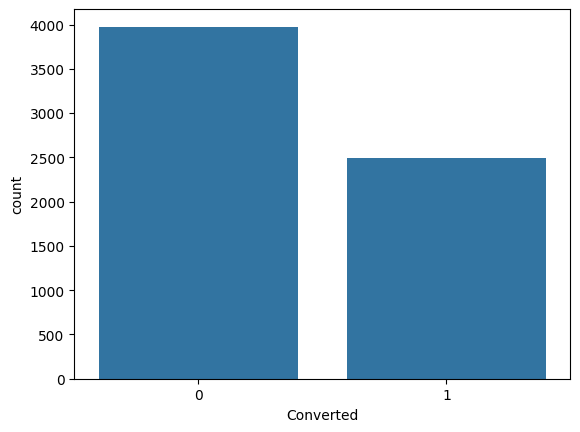

In [156]:
sns.countplot(x="Converted",data =train)


In [157]:

train.drop( ["Id", "Prospect ID", "Lead Number"], axis=1, inplace=True)
test.drop(["Id", "Prospect ID", "Lead Number"],axis=1,inplace=True)

In [158]:
train.shape


(6468, 35)

In [159]:
test.shape

(2772, 34)

In [160]:
constant_columns = ["Magazine","Receive More Updates About Our Courses","Update me on Supply Chain Content",
                    "Get updates on DM Content","I agree to pay the amount through cheque"
                    ]

train.drop(columns=constant_columns, inplace=True)
test.drop(columns=constant_columns, inplace=True)

In [161]:
train.shape

(6468, 30)

In [162]:
test.shape

(2772, 29)

In [163]:
train["TotalVisits"].describe()

count    6367.000000
mean        3.413853
std         5.033449
min         0.000000
25%         1.000000
50%         3.000000
75%         5.000000
max       251.000000
Name: TotalVisits, dtype: float64

In [164]:
median_totalvisits = train["TotalVisits"].median()

train["TotalVisits"].fillna(median_totalvisits, inplace=True)
test["TotalVisits"].fillna(median_totalvisits, inplace=True)

C:\Users\alaka\AppData\Local\Temp\ipykernel_19816\2216894027.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train["TotalVisits"].fillna(median_totalvisits, inplace=True)
C:\Users\alaka\AppData\Local\Temp\ipykernel_19816\2216894027.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a c

In [165]:
train["TotalVisits"].isnull().sum()

np.int64(0)

In [166]:
test["TotalVisits"].isnull().sum()

np.int64(0)

In [167]:
train["Page Views Per Visit"].describe()

count    6367.000000
mean        2.363868
std         2.216209
min         0.000000
25%         1.000000
50%         2.000000
75%         3.000000
max        55.000000
Name: Page Views Per Visit, dtype: float64

In [168]:
median_pageviews=train["Page Views Per Visit"].median()
train["Page Views Per Visit"].fillna(median_pageviews, inplace=True)
test["Page Views Per Visit"].fillna(median_pageviews, inplace=True)


C:\Users\alaka\AppData\Local\Temp\ipykernel_19816\2227441009.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train["Page Views Per Visit"].fillna(median_pageviews, inplace=True)
C:\Users\alaka\AppData\Local\Temp\ipykernel_19816\2227441009.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves

In [169]:
train["Page Views Per Visit"].isnull().sum()    

np.int64(0)

In [170]:
test["Page Views Per Visit"].isnull().sum()

np.int64(0)

In [171]:
train["Lead Source"].value_counts()

Lead Source
Google              2004
Direct Traffic      1787
Olark Chat          1219
Organic Search       797
Reference            387
Welingak Website     101
Referral Sites        94
Facebook              40
google                 4
bing                   2
Press_Release          2
testone                1
Click2call             1
WeLearn                1
Live Chat              1
welearnblog_Home       1
Name: count, dtype: int64

In [172]:
mode_leadsource = train["Lead Source"].mode()[0]

train["Lead Source"] = train["Lead Source"].fillna(mode_leadsource)

test["Lead Source"] = test["Lead Source"].fillna(mode_leadsource)

In [173]:
train["Lead Source"].isnull().sum()

np.int64(0)

In [174]:
test["Lead Source"].isnull().sum()

np.int64(0)

In [175]:
train["Last Activity"].value_counts()

Last Activity
Email Opened                    2403
SMS Sent                        1906
Olark Chat Conversation          662
Page Visited on Website          454
Converted to Lead                299
Email Bounced                    239
Email Link Clicked               189
Form Submitted on Website         87
Unreachable                       72
Unsubscribed                      44
Had a Phone Conversation          27
Approached upfront                 6
View in browser link Clicked       5
Email Received                     1
Name: count, dtype: int64

In [176]:
mode_lastactivity = train["Last Activity"].mode()[0]
train["Last Activity"] = train["Last Activity"].fillna(mode_lastactivity)
test["Last Activity"] = test["Last Activity"].fillna(mode_lastactivity)

In [177]:
train["Last Activity"].isnull().sum()

np.int64(0)

In [178]:
test['Last Activity'].isnull().sum()

np.int64(0)

In [179]:
train["Country"] = train["Country"].fillna("Unknown")
test["Country"] = test["Country"].fillna("Unknown")

In [180]:
train.isnull().sum().sort_values(ascending=False)

Lead Quality                                     3309
Asymmetrique Profile Score                       2933
Asymmetrique Profile Index                       2933
Asymmetrique Activity Index                      2933
Asymmetrique Activity Score                      2933
Tags                                             2326
What matters most to you in choosing a course    1867
Lead Profile                                     1867
What is your current occupation                  1854
How did you hear about X Education               1523
Specialization                                    994
City                                              980
Lead Origin                                         0
Lead Source                                         0
Total Time Spent on Website                         0
Page Views Per Visit                                0
Last Activity                                       0
Country                                             0
Do Not Email                

In [181]:
train["City"]=train["City"].fillna("Unknown")
test["City"]=test["City"].fillna("Unknown")

In [182]:
train["City"].isnull().sum()

np.int64(0)

In [183]:
test['City'].isnull().sum()

np.int64(0)

In [184]:
train["Specialization"].value_counts()

Specialization
Select                               1368
Finance Management                    693
Human Resource Management             597
Marketing Management                  573
Operations Management                 356
Business Administration               273
Supply Chain Management               257
IT Projects Management                238
Banking, Investment And Insurance     229
Travel and Tourism                    155
Media and Advertising                 142
International Business                128
Healthcare Management                 110
Hospitality Management                 84
E-COMMERCE                             79
Retail Management                      76
Rural and Agribusiness                 49
E-Business                             37
Services Excellence                    30
Name: count, dtype: int64

In [185]:
train["Specialization"] = train["Specialization"].fillna("Unknown")

test["Specialization"] = test["Specialization"].fillna("Unknown")

In [186]:
train["Specialization"].isnull().sum()

np.int64(0)

In [187]:
train["What is your current occupation"] = train["What is your current occupation"].fillna("Unknown")

test["What is your current occupation"] = test["What is your current occupation"].fillna("Unknown")

In [188]:
train["What is your current occupation"].isnull().sum()

np.int64(0)

In [189]:
train["Lead Profile"] = train["Lead Profile"].fillna("Unknown")

test["Lead Profile"] = test["Lead Profile"].fillna("Unknown")

In [190]:
train['Lead Profile'].isnull().sum()

np.int64(0)

In [191]:
train["What matters most to you in choosing a course"].value_counts(dropna=False)

What matters most to you in choosing a course
Better Career Prospects      4599
NaN                          1867
Flexibility & Convenience       2
Name: count, dtype: int64

In [192]:
mode_course = train["What matters most to you in choosing a course"].mode()[0]

train["What matters most to you in choosing a course"] = train["What matters most to you in choosing a course"].fillna(mode_course)

test["What matters most to you in choosing a course"] = test["What matters most to you in choosing a course"].fillna(mode_course)

In [193]:
train["What matters most to you in choosing a course"].isnull().sum()

np.int64(0)

In [194]:
train["How did you hear about X Education"] = train["How did you hear about X Education"].fillna("Unknown")

test["How did you hear about X Education"] = test["How did you hear about X Education"].fillna("Unknown")

In [195]:
train['How did you hear about X Education'].isnull().sum()

np.int64(0)

In [196]:
train["Lead Quality"].value_counts(dropna=False)

Lead Quality
NaN                  3309
Might be             1123
Not Sure              761
High in Relevance     446
Worst                 420
Low in Relevance      409
Name: count, dtype: int64

In [197]:
train["Lead Quality"] = train["Lead Quality"].fillna("Unknown")

test["Lead Quality"] = test["Lead Quality"].fillna("Unknown")

In [198]:
train['Lead Quality'].isnull().sum()

np.int64(0)

In [199]:
train["Tags"].value_counts(dropna=False)

Tags
NaN                                                  2326
Will revert after reading the email                  1468
Ringing                                               858
Interested in other courses                           349
Already a student                                     332
Closed by Horizzon                                    262
switched off                                          158
Busy                                                  128
Lost to EINS                                          114
Not doing further education                           104
Graduation in progress                                 83
Interested  in full time MBA                           79
invalid number                                         55
Diploma holder (Not Eligible)                          47
wrong number given                                     30
opp hangup                                             23
number not provided                                    18
in touch 

In [200]:
train["Tags"] = train["Tags"].fillna("Unknown")

test["Tags"] = test["Tags"].fillna("Unknown")

In [201]:
train['Tags'].isnull().sum()

np.int64(0)

In [202]:
train[["Asymmetrique Activity Score", "Asymmetrique Activity Index",  "Asymmetrique Profile Score", "Asymmetrique Profile Index"]].describe()

,Asymmetrique Activity Score,Asymmetrique Profile Score
count,3535.000000,3535.000000
mean,14.296181,16.334371
std,1.401642,1.810550
min,7.000000,11.000000
25%,14.000000,15.000000
50%,14.000000,16.000000
75%,15.000000,18.000000
max,18.000000,20.000000


In [203]:
activityscore_median = train["Asymmetrique Activity Score"].median()

profilescore_median = train["Asymmetrique Profile Score"].median()


train["Asymmetrique Activity Score"] = train["Asymmetrique Activity Score"].fillna(activityscore_median)

test["Asymmetrique Activity Score"] = test["Asymmetrique Activity Score"].fillna(activityscore_median)

train["Asymmetrique Profile Score"] = train["Asymmetrique Profile Score"].fillna(profilescore_median)

test["Asymmetrique Profile Score"] = test["Asymmetrique Profile Score"].fillna(profilescore_median)

In [204]:
train["Asymmetrique Activity Score"].isnull().sum()

np.int64(0)

In [205]:
train["Asymmetrique Activity Index"].value_counts(dropna=False)

Asymmetrique Activity Index
NaN          2933
02.Medium    2700
01.High       573
03.Low        262
Name: count, dtype: int64

In [206]:

train["Asymmetrique Profile Index"].value_counts(dropna=False)

Asymmetrique Profile Index
NaN          2933
02.Medium    1977
01.High      1535
03.Low         23
Name: count, dtype: int64

In [207]:
train["Asymmetrique Activity Index"] = train["Asymmetrique Activity Index"].fillna("Unknown")

test["Asymmetrique Activity Index"] = test["Asymmetrique Activity Index"].fillna("Unknown")

In [208]:
train["Asymmetrique Profile Index"] = train["Asymmetrique Profile Index"].fillna("Unknown")

test["Asymmetrique Profile Index"] = test["Asymmetrique Profile Index"].fillna("Unknown")

In [236]:
train.isnull().sum().sort_values(ascending=False)

Lead Origin                                      0
Lead Source                                      0
Do Not Email                                     0
Do Not Call                                      0
Converted                                        0
TotalVisits                                      0
Total Time Spent on Website                      0
Page Views Per Visit                             0
Last Activity                                    0
Country                                          0
Specialization                                   0
How did you hear about X Education               0
What is your current occupation                  0
What matters most to you in choosing a course    0
Search                                           0
Newspaper Article                                0
X Education Forums                               0
Newspaper                                        0
Digital Advertisement                            0
Through Recommendations        

In [237]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6468 entries, 0 to 6467
Data columns (total 30 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Lead Origin                                    6468 non-null   object 
 1   Lead Source                                    6468 non-null   object 
 2   Do Not Email                                   6468 non-null   object 
 3   Do Not Call                                    6468 non-null   object 
 4   Converted                                      6468 non-null   int64  
 5   TotalVisits                                    6468 non-null   float64
 6   Total Time Spent on Website                    6468 non-null   int64  
 7   Page Views Per Visit                           6468 non-null   float64
 8   Last Activity                                  6468 non-null   object 
 9   Country                                        6468 

In [238]:
print(train.shape)
print(test.shape)

(6468, 30)
(2772, 168)


In [239]:
X = train.drop("Converted", axis=1)

y = train["Converted"]

In [240]:
X.shape

(6468, 29)

In [241]:
y.shape

(6468,)

In [242]:
binary_cols = [
    "Do Not Email","Do Not Call",  "Search","Newspaper Article", "X Education Forums",
    "Newspaper", "Digital Advertisement",  "Through Recommendations", "A free copy of Mastering The Interview"   ]

for col in binary_cols:
    X[col] = X[col].map({"Yes": 1, "No": 0})
    test[col] = test[col].map({"Yes": 1, "No": 0})

In [243]:
lead_quality_map = { "Worst": 0, "Low in Relevance": 1, "Not Sure": 2, "Might be": 3, "High in Relevance": 4, "Unknown": 5}

X["Lead Quality"] = X["Lead Quality"].map(lead_quality_map)
test["Lead Quality"] = test["Lead Quality"].map(lead_quality_map)

In [244]:
activity_map = {
    "03.Low": 0,
    "02.Medium": 1,
    "01.High": 2,
    "Unknown": -1
}

X["Asymmetrique Activity Index"] = X["Asymmetrique Activity Index"].map(activity_map)
test["Asymmetrique Activity Index"] = test["Asymmetrique Activity Index"].map(activity_map)

In [245]:
profile_map = {
    "03.Low": 0,
    "02.Medium": 1,
    "01.High": 2,
    "Unknown": -1
}

X["Asymmetrique Profile Index"] = X["Asymmetrique Profile Index"].map(profile_map)
test["Asymmetrique Profile Index"] = test["Asymmetrique Profile Index"].map(profile_map)

In [246]:
cat_cols = X.select_dtypes(include="object").columns


In [247]:
X = pd.get_dummies(X,columns=cat_cols,drop_first=True,dtype=int)

In [248]:

test_cat_cols = test.select_dtypes(include="object").columns


test = pd.get_dummies(test,columns=test_cat_cols,drop_first=True,dtype=int)


In [249]:
X, test = X.align(test, join="left", axis=1, fill_value=0)

In [250]:
X.shape


(6468, 168)

In [251]:
test.shape

(2772, 168)

In [252]:
X.head()

,Do Not Email,Do Not Call,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Search,Newspaper Article,X Education Forums,Newspaper,Digital Advertisement,...,Last Notable Activity_Email Opened,Last Notable Activity_Email Received,Last Notable Activity_Form Submitted on Website,Last Notable Activity_Had a Phone Conversation,Last Notable Activity_Modified,Last Notable Activity_Olark Chat Conversation,Last Notable Activity_Page Visited on Website,Last Notable Activity_SMS Sent,Last Notable Activity_Unreachable,Last Notable Activity_Unsubscribed
0,0,0,4.0,198,4.0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
1,0,0,0.0,0,0.0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,0,0,2.0,1099,2.0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
3,0,0,4.0,1381,4.0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,0,0,8.0,1484,8.0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [253]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(  X,  y,  test_size=0.2,  random_state=42)

In [254]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_valid_scaled = scaler.transform(X_valid)

test_scaled = scaler.transform(test)

In [255]:

from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [256]:
y_pred_lr = model.predict(X_valid_scaled)
y_pred_lr

array([0, 0, 0, ..., 0, 1, 1], shape=(1294,))

In [258]:
from sklearn.metrics import (confusion_matrix,accuracy_score,precision_score,recall_score,f1_score)

In [259]:
print("Accuracy :", accuracy_score(y_valid, y_pred_lr))
print("Precision :", precision_score(y_valid, y_pred_lr))
print("lr_Recall :", recall_score(y_valid, y_pred_lr))
print("F1 :", f1_score(y_valid, y_pred_lr))
lr_Recall = recall_score(y_valid, y_pred_lr)

Accuracy : 0.9412673879443586
Precision : 0.936734693877551
lr_Recall : 0.9107142857142857
F1 : 0.9235412474849095


In [260]:
cm = confusion_matrix(y_valid, y_pred_lr)

print(cm)

[[759  31]
 [ 45 459]]


In [261]:
from sklearn.tree import DecisionTreeClassifier
model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train, y_train)
y_pred_dt = model_dt.predict(X_valid)

In [262]:
print("Accuracy :", accuracy_score(y_valid, y_pred_dt))
print("Precision :", precision_score(y_valid, y_pred_dt))
print("dt_Recall :", recall_score(y_valid, y_pred_dt))
print("F1 :", f1_score(y_valid, y_pred_dt))
dt_Recall = recall_score(y_valid, y_pred_dt)

Accuracy : 0.9343122102009274
Precision : 0.9266802443991853
dt_Recall : 0.9027777777777778
F1 : 0.914572864321608


In [263]:
cm_dt = confusion_matrix(y_valid, y_pred_dt)
cm_dt

array([[754,  36],
       [ 49, 455]])

In [264]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(random_state=42)

model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_valid)

In [265]:
print("Accuracy :", accuracy_score(y_valid, y_pred_rf))
print("Precision :", precision_score(y_valid, y_pred_rf))
print("rf_Recall :", recall_score(y_valid, y_pred_rf))
print("F1 :", f1_score(y_valid, y_pred_rf))
rf_Recall = recall_score(y_valid, y_pred_rf)

Accuracy : 0.9451313755795981
Precision : 0.944558521560575
rf_Recall : 0.9126984126984127
F1 : 0.9283551967709385


In [266]:
cm_rf = confusion_matrix(y_valid, y_pred_rf)
cm_rf

array([[763,  27],
       [ 44, 460]])

In [267]:
from sklearn.neighbors import KNeighborsClassifier
model_knn = KNeighborsClassifier()

model_knn.fit(X_train_scaled, y_train)

y_pred_knn = model_knn.predict(X_valid_scaled)

In [268]:
print("Accuracy :", accuracy_score(y_valid, y_pred_knn))
print("Precision :", precision_score(y_valid, y_pred_knn))
print("knn_Recall :", recall_score(y_valid, y_pred_knn))
print("F1 :", f1_score(y_valid, y_pred_knn))
knn_Recall = recall_score(y_valid, y_pred_knn)

Accuracy : 0.8693972179289027
Precision : 0.8747203579418344
knn_Recall : 0.7757936507936508
F1 : 0.8222923238696109


In [269]:
cm_knn = confusion_matrix(y_valid, y_pred_knn)
cm_knn

array([[734,  56],
       [113, 391]])

In [270]:
import sys

!{sys.executable} -m pip install xgboost


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [271]:
from xgboost import XGBClassifier

model_xgb = XGBClassifier(random_state=42)

model_xgb.fit(X_train, y_train)

y_pred_xgb = model_xgb.predict(X_valid)

In [272]:
print("Accuracy :", accuracy_score(y_valid, y_pred_xgb))
print("Precision :", precision_score(y_valid, y_pred_xgb))
print("xgb_Recall :", recall_score(y_valid, y_pred_xgb))
print("F1 :", f1_score(y_valid, y_pred_xgb))
xgb_Recall = recall_score(y_valid, y_pred_xgb)

Accuracy : 0.9435857805255023
Precision : 0.9371196754563894
xgb_Recall : 0.9166666666666666
F1 : 0.9267803410230692


In [273]:

cm_xgb = confusion_matrix(y_valid, y_pred_xgb)
cm_xgb

array([[759,  31],
       [ 42, 462]])

In [274]:
from sklearn.ensemble import GradientBoostingClassifier
model_gb = GradientBoostingClassifier(random_state=42)
model_gb.fit(X_train, y_train)
y_pred_gb = model_gb.predict(X_valid)

In [275]:
print("Accuracy :", accuracy_score(y_valid, y_pred_gb))
print("Precision :", precision_score(y_valid, y_pred_gb))
print("gb_Recall :", recall_score(y_valid, y_pred_gb))
print("F1 :", f1_score(y_valid, y_pred_gb))
gb_Recall = recall_score(y_valid, y_pred_gb)

Accuracy : 0.9466769706336939
Precision : 0.9503105590062112
gb_Recall : 0.9107142857142857
F1 : 0.9300911854103343


In [276]:
cm_gb = confusion_matrix(y_valid, y_pred_gb)
cm_gb

array([[766,  24],
       [ 45, 459]])

In [277]:
from sklearn.ensemble import AdaBoostClassifier
model_ab = AdaBoostClassifier(random_state=42)
model_ab.fit(X_train, y_train)
y_pred_ab = model_ab.predict(X_valid)

In [278]:
print("Accuracy :", accuracy_score(y_valid, y_pred_ab))
print("Precision :", precision_score(y_valid, y_pred_ab))
print("ab_Recall :", recall_score(y_valid, y_pred_ab))
print("F1 :", f1_score(y_valid, y_pred_ab))
ab_Recall = recall_score(y_valid, y_pred_ab)

Accuracy : 0.9281298299845441
Precision : 0.9438444924406048
ab_Recall : 0.8670634920634921
F1 : 0.9038262668045501


In [279]:
cm_ab = confusion_matrix(y_valid, y_pred_ab)
cm_ab

array([[764,  26],
       [ 67, 437]])

In [280]:
import sys

!{sys.executable} -m pip install catboost


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [281]:
from catboost import CatBoostClassifier
model_cb = CatBoostClassifier(
    random_state=42,
    verbose=0)
model_cb.fit(X_train, y_train)      
y_pred_cb = model_cb.predict(X_valid)

In [282]:
print("Accuracy :", accuracy_score(y_valid, y_pred_cb))
print("Precision :", precision_score(y_valid, y_pred_cb))
print("cb_Recall :", recall_score(y_valid, y_pred_cb))
print("F1 :", f1_score(y_valid, y_pred_cb))
cb_Recall = recall_score(y_valid, y_pred_cb)


Accuracy : 0.9474497681607419
Precision : 0.9412955465587044
cb_Recall : 0.9226190476190477
F1 : 0.9318637274549099


In [283]:
cm_cb = confusion_matrix(y_valid, y_pred_cb)
cm_cb

array([[761,  29],
       [ 39, 465]])

In [284]:


recall_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "AdaBoost",
        "XGBoost",
        "CatBoost"
    ],
    "Recall": [
        lr_Recall,
        knn_Recall,
        dt_Recall,
        rf_Recall,
        gb_Recall,
        ab_Recall,
        xgb_Recall,
        cb_Recall
    ]
})

print(recall_df)

                 Model    Recall
0  Logistic Regression  0.910714
1                  KNN  0.775794
2        Decision Tree  0.902778
3        Random Forest  0.912698
4    Gradient Boosting  0.910714
5             AdaBoost  0.867063
6              XGBoost  0.916667
7             CatBoost  0.922619


Best Model: CatBoost

In [286]:
test_pred = model_cb.predict(test)
test_pred

array([0, 1, 0, ..., 0, 1, 1], shape=(2772,))

In [287]:
submission = pd.DataFrame({
    "ID": test_id,
    "Converted": test_pred
})

In [288]:
submission.head()

,ID,Converted
0,8305,0
1,1591,1
2,8604,0
3,1333,0
4,4260,0


In [289]:
submission.to_csv("submission.csv", index=False)

In [290]:
lead_probability = model_cb.predict_proba(test)[:, 1]
lead_score = (lead_probability * 100).round(2)

In [291]:
lead_score_df = pd.DataFrame({
    "ID": test_id,
    "Lead_Score": lead_score
})


In [292]:
lead_score_df

,ID,Lead_Score
0,8305,0.67
1,1591,89.89
2,8604,1.04
3,1333,0.97
4,4260,0.25
...,...,...
2767,482,93.55
2768,310,0.53
2769,8066,1.76
2770,8581,67.99
